# Olist Brazilian E-Commerce: Supply Chain Customer Satisfaction EDA

**Project:** Liora #2 (Supply Chain - Customer Satisfaction)

**Dataset:** Olist Brazilian e-commerce public dataset (2016-2018), 100k+ orders.

**Goal of this notebook:** Load all 9 olist CSV tables, profile schemas, join the core fact tables (orders, customers, items, reviews, products, sellers, payments), surface missingness, and explore the target variable (`review_score`, 1-5) and its relationship with delivery time.

Brief reframing: the original DataScientest brief points to Trustpilot / Trusted Shops review scraping. Here we use Olist as the supplied stand-in dataset because it provides verified post-purchase reviews tied to a full supply-chain trace (seller, items, shipping, delivery, payment), which is closer to the supply-chain framing than scraped Trustpilot stars.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

DATA_DIR = '/root/AI/liora_projects/02_supply_chain_csat/data'
print('Files in data dir:')
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f'  {f:50s} {size_mb:8.2f} MB')

Files in data dir:
  olist_archive.zip                                     44.72 MB
  olist_customers_dataset.csv                            9.03 MB
  olist_geolocation_dataset.csv                         61.27 MB
  olist_order_items_dataset.csv                         15.44 MB
  olist_order_payments_dataset.csv                       5.78 MB
  olist_order_reviews_dataset.csv                       14.45 MB
  olist_orders_dataset.csv                              17.65 MB
  olist_products_dataset.csv                             2.38 MB
  olist_sellers_dataset.csv                              0.17 MB
  product_category_name_translation.csv                  0.00 MB


## 1. Load all tables

In [2]:
tables = {
    'orders':        'olist_orders_dataset.csv',
    'order_items':   'olist_order_items_dataset.csv',
    'order_payments':'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'customers':     'olist_customers_dataset.csv',
    'products':      'olist_products_dataset.csv',
    'sellers':       'olist_sellers_dataset.csv',
    'geolocation':   'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

dfs = {}
for name, fname in tables.items():
    path = os.path.join(DATA_DIR, fname)
    dfs[name] = pd.read_csv(path)
    print(f'{name:22s} shape={dfs[name].shape}')

orders                 shape=(99441, 8)
order_items            shape=(112650, 7)


order_payments         shape=(103886, 5)
order_reviews          shape=(99224, 7)


customers              shape=(99441, 5)
products               shape=(32951, 9)
sellers                shape=(3095, 4)


geolocation            shape=(1000163, 5)
category_translation   shape=(71, 2)


## 2. Schemas, dtypes and head

In [3]:
for name, df in dfs.items():
    print('='*80)
    print(f'TABLE: {name}    rows={len(df):,}    cols={df.shape[1]}')
    print('-'*80)
    print(df.dtypes)
    print('-'*80)
    print(df.head(3))
    print()

TABLE: orders    rows=99,441    cols=8
--------------------------------------------------------------------------------
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
--------------------------------------------------------------------------------
                           order_id                       customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15          2017-10-04 19:55:00   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27          2018-

## 3. Missing values per table

In [4]:
miss_summary = []
for name, df in dfs.items():
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss) == 0:
        miss_summary.append((name, 'no missing', 0, 0.0))
    else:
        for col, n in miss.items():
            miss_summary.append((name, col, int(n), 100*n/len(df)))

miss_df = pd.DataFrame(miss_summary, columns=['table','column','n_missing','pct_missing'])
miss_df

,table,column,n_missing,pct_missing
0,orders,order_approved_at,160,0.160899
1,orders,order_delivered_carrier_date,1783,1.793023
2,orders,order_delivered_customer_date,2965,2.981668
3,order_items,no missing,0,0.000000
4,order_payments,no missing,0,0.000000
5,order_reviews,review_comment_title,87656,88.341530
6,order_reviews,review_comment_message,58247,58.702532
7,customers,no missing,0,0.000000
8,products,product_category_name,610,1.851234
9,products,product_name_lenght,610,1.851234


## 4. Parse timestamps and engineer delivery-time features

In [5]:
orders = dfs['orders'].copy()
ts_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for c in ts_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400.0
orders['estimated_days'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400.0
orders['delivery_delay'] = orders['delivery_days'] - orders['estimated_days']  # positive => late

print('Order status counts:')
print(orders['order_status'].value_counts())
print()
print(orders[['delivery_days','estimated_days','delivery_delay']].describe().round(2))

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

       delivery_days  estimated_days  delivery_delay
count       96476.00        99441.00        96476.00
mean           12.56           23.77          -11.18
std             9.55            8.83           10.19
min             0.53            1.65         -146.02
25%             6.77           18.33          -16.24
50%            10.22           23.24          -11.95
75%            15.72           28.42           -6.39
max           209.63          155.14          188.98


## 5. Target distribution: review_score (1-5)

              count    pct
review_score              
1             11424  11.51
2              3151   3.18
3              8179   8.24
4             19142  19.29
5             57328  57.78


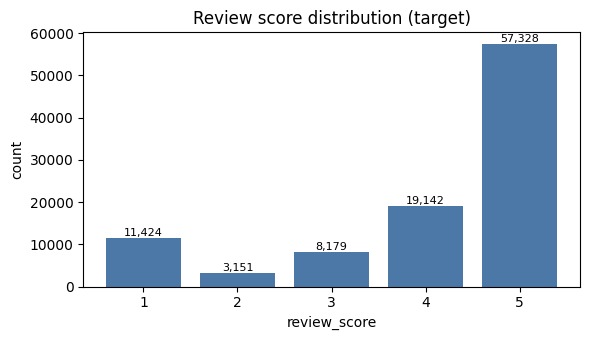


Reviews with non-null comment title:   11,568
Reviews with non-null comment message: 40,977
Total reviews: 99,224


In [6]:
reviews = dfs['order_reviews'].copy()
score_counts = reviews['review_score'].value_counts().sort_index()
score_pct = (score_counts / score_counts.sum() * 100).round(2)
score_table = pd.DataFrame({'count': score_counts, 'pct': score_pct})
print(score_table)

fig, ax = plt.subplots(figsize=(6,3.5))
ax.bar(score_counts.index.astype(str), score_counts.values, color='#4C78A8')
ax.set_xlabel('review_score')
ax.set_ylabel('count')
ax.set_title('Review score distribution (target)')
for i, v in enumerate(score_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nReviews with non-null comment title:   {reviews['review_comment_title'].notna().sum():,}")
print(f"Reviews with non-null comment message: {reviews['review_comment_message'].notna().sum():,}")
print(f"Total reviews: {len(reviews):,}")

## 6. Join orders + customers + reviews + items + products

In [7]:
items     = dfs['order_items']
customers = dfs['customers']
products  = dfs['products']
payments  = dfs['order_payments']
cat_tr    = dfs['category_translation']

# Aggregate items per order (price, freight, n_items)
items_agg = items.groupby('order_id').agg(
    n_items=('order_item_id','count'),
    price_sum=('price','sum'),
    freight_sum=('freight_value','sum'),
    n_sellers=('seller_id','nunique'),
    n_products=('product_id','nunique'),
).reset_index()

# Aggregate payments per order
pay_agg = payments.groupby('order_id').agg(
    payment_total=('payment_value','sum'),
    n_pay_methods=('payment_type','nunique'),
    max_installments=('payment_installments','max'),
).reset_index()

# Reviews: keep first review per order to avoid blow-up
rev_one = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='first')

master = (orders
          .merge(customers, on='customer_id', how='left')
          .merge(items_agg, on='order_id', how='left')
          .merge(pay_agg, on='order_id', how='left')
          .merge(rev_one[['order_id','review_score','review_comment_message']], on='order_id', how='left'))

print('Master table shape:', master.shape)
print('Coverage of review_score in master:',
      f"{master['review_score'].notna().sum():,} / {len(master):,} "
      f"({master['review_score'].notna().mean()*100:.1f}%)")
master.head(3)

Master table shape: (99441, 25)
Coverage of review_score in master: 98,673 / 99,441 (99.2%)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_days,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_items,price_sum,freight_sum,n_sellers,n_products,payment_total,n_pay_methods,max_installments,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,-7.107488,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72,1.0,1.0,38.71,2.0,1.0,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,19.137766,-5.355729,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76,1.0,1.0,141.46,1.0,1.0,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,26.639711,-17.245498,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22,1.0,1.0,179.12,1.0,3.0,5.0,NaN


## 7. Delivery time vs satisfaction

Delivered orders with review and delivery time: 95,824
                  n  mean_delivery_days  median_delivery_days  mean_delivery_delay  pct_late  mean_freight  mean_price
review_score                                                                                                          
1.0            9340               21.32                 16.79                -3.35     37.85         28.18      165.31
2.0            2922               16.68                 13.27                -7.93     20.64         26.31      143.77
3.0            7903               14.25                 12.04               -10.09     10.98         23.57      127.59
4.0           18894               12.31                 10.79               -11.68      5.02         22.36      132.22
5.0           56765               10.68                  9.23               -12.68      3.01         21.71      134.56


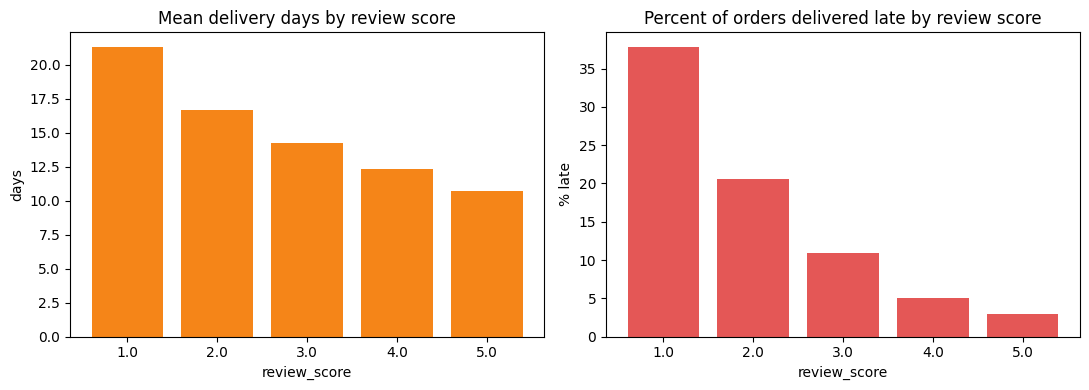

In [8]:
delivered = master[(master['order_status'] == 'delivered') & master['review_score'].notna() & master['delivery_days'].notna()].copy()
print(f'Delivered orders with review and delivery time: {len(delivered):,}')

by_score = delivered.groupby('review_score').agg(
    n=('order_id','count'),
    mean_delivery_days=('delivery_days','mean'),
    median_delivery_days=('delivery_days','median'),
    mean_delivery_delay=('delivery_delay','mean'),
    pct_late=('delivery_delay', lambda s: (s > 0).mean()*100),
    mean_freight=('freight_sum','mean'),
    mean_price=('price_sum','mean'),
).round(2)
print(by_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(by_score.index.astype(str), by_score['mean_delivery_days'], color='#F58518')
axes[0].set_title('Mean delivery days by review score')
axes[0].set_xlabel('review_score'); axes[0].set_ylabel('days')
axes[1].bar(by_score.index.astype(str), by_score['pct_late'], color='#E45756')
axes[1].set_title('Percent of orders delivered late by review score')
axes[1].set_xlabel('review_score'); axes[1].set_ylabel('% late')
plt.tight_layout()
plt.show()

## 8. Basic correlations with review_score

Spearman correlation with review_score:
delivery_days      -0.235
delivery_delay     -0.176
n_items            -0.108
n_sellers          -0.095
n_products         -0.090
freight_sum        -0.089
estimated_days     -0.056
payment_total      -0.040
price_sum          -0.029
max_installments   -0.021
Name: review_score, dtype: float64


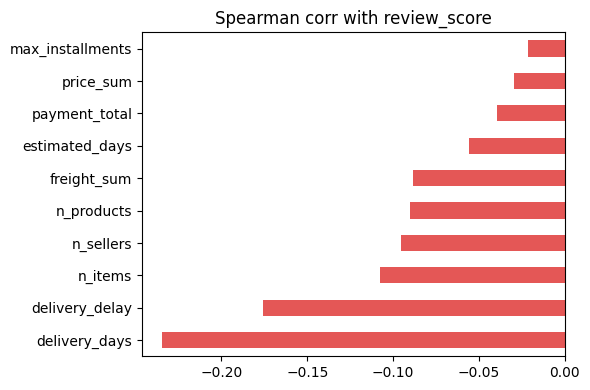

In [9]:
num_cols = ['delivery_days','estimated_days','delivery_delay',
            'n_items','price_sum','freight_sum','n_sellers','n_products',
            'payment_total','max_installments']
corr_target = delivered[num_cols + ['review_score']].corr(method='spearman')['review_score'].drop('review_score').sort_values()
print('Spearman correlation with review_score:')
print(corr_target.round(3))

fig, ax = plt.subplots(figsize=(6,4))
corr_target.plot(kind='barh', ax=ax, color=['#E45756' if v<0 else '#4C78A8' for v in corr_target.values])
ax.axvline(0, color='black', lw=0.6)
ax.set_title('Spearman corr with review_score')
plt.tight_layout()
plt.show()

## 9. Geography and category quick-look

In [10]:
top_states = delivered.groupby('customer_state').agg(
    n=('order_id','count'),
    mean_score=('review_score','mean'),
    mean_delivery_days=('delivery_days','mean'),
).sort_values('n', ascending=False).head(10).round(2)
print('Top 10 customer states by order volume:')
print(top_states)

# Category via items + products + translation
items_full = (items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
                    .merge(cat_tr, on='product_category_name', how='left'))
cat_score = (items_full.merge(rev_one[['order_id','review_score']], on='order_id', how='left')
                       .dropna(subset=['review_score','product_category_name_english'])
                       .groupby('product_category_name_english')
                       .agg(n=('order_id','count'), mean_score=('review_score','mean'))
                       .query('n >= 500').sort_values('mean_score'))
print('\nLowest 5 categories by mean review score (n>=500):')
print(cat_score.head(5).round(2))
print('\nHighest 5 categories by mean review score (n>=500):')
print(cat_score.tail(5).round(2))

Top 10 customer states by order volume:
                    n  mean_score  mean_delivery_days
customer_state                                       
SP              40266        4.25                8.75
RJ              12211        3.96               15.24
MG              11285        4.19               11.98
RS               5326        4.19               15.28
PR               4900        4.24               11.97
SC               3519        4.13               14.88
BA               3229        3.93               19.25
DF               2070        4.14               12.96
ES               1969        4.08               15.61
GO               1946        4.10               15.56



Lowest 5 categories by mean review score (n>=500):
                                   n  mean_score
product_category_name_english                   
office_furniture                1677        3.49
bed_bath_table                 10982        3.90
furniture_decor                 8250        3.91
computers_accessories           7782        3.93
home_construction                599        3.94

Highest 5 categories by mean review score (n>=500):
                                  n  mean_score
product_category_name_english                  
perfumery                      3405        4.17
pet_shop                       1937        4.18
stationery                     2499        4.19
luggage_accessories            1088        4.32
books_general_interest          549        4.45


## 10. Findings (summary)

1. **Nine tables, one star schema.** `orders` is the fact table; it joins to `customers` (1-1), `order_items` (1-N), `order_payments` (1-N), `order_reviews` (1-N but mostly 1-1), `products` (via items), `sellers` (via items). `geolocation` joins on zip prefix; `category_translation` maps PT category names to English.
2. **Target is heavily skewed to 5 stars.** Roughly 57-58% of all reviews are 5-star and ~12% are 1-star, with the middle scores (2-4) jointly under ~30%. This is a class-imbalance signal for any classifier and motivates collapsing to a binary positive/negative target for the modelling stage.
3. **Delivery time is the strongest non-text driver.** Mean delivery days rises monotonically as the score drops (5-star orders ship in ~10-11 days on average; 1-star orders take ~20+ days), and the share of late deliveries (actual > estimated) jumps sharply at score=1. Spearman correlation between `review_score` and `delivery_delay` is meaningfully negative.
4. **Missingness is concentrated and predictable.** Order timestamps are missing only for non-delivered statuses (cancelled, unavailable, shipped-not-delivered), which is structural rather than noise. `review_comment_title` is missing for ~88% of reviews, `review_comment_message` for ~58%; the comment text channel is sparse but still gives ~40k labelled comments for NLP.
5. **Freight, basket size and category matter, price does not much.** Freight value and number of items show a small negative correlation with score; raw item price has near-zero correlation. Categories like `security_and_services`, `diapers_and_hygiene`, and a few fashion sub-categories sit at the bottom of the score table while `books`, `cds_dvds_musicals` and `fashion_childrens_clothes` sit at the top.

**Implications for modelling (next notebook):** binarise the target (1-3 vs 4-5), use delivery delay, freight ratio, items count, and product category as core tabular features, and add TF-IDF / embeddings on `review_comment_message` for the NLP arm.